## SUPPORTLYTICS - Milestone 1: Data Setup & Feature Engineering


### 1. Module 1:- Project Initialization and Dataset setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler
import plotly.express as px

In [3]:
# Define Project Objectives and KPIs

print("\nPrimary Goal")
print("- Analyze IT support ticket data to improve resolution time and service efficiency.")

print("\nSecondary Goals")
print("1. Identify performance trends across regions and ticket types.")
print("2. Find common customer requests and technical issues.")
print("3. Group similar issues to improve resource allocation.")
print("4. Suggest workflow improvements based on data analysis.")

print("\nKey Performance Indicators (KPIs)")
print("1. Average Resolution Time")
print("   - Average time taken to resolve a ticket (hours).")

print("2. First Response Time")
print("   - Time taken to respond to a ticket for the first time.")

print("3. SLA Compliance Rate")
print("   - Percentage of tickets resolved within the SLA.")

print("4. Customer Satisfaction")
print("   - Average customer rating (1-5).")

print("5. Ticket Volume")
print("   - Number of tickets by region, priority, and category.")

print("6. Escalation Rate")
print("   - Percentage of tickets that were escalated.")

print("7. Resolution Rate by Priority")
print("   - Number of resolved tickets for each priority level.")

print("8. Top Issue Categories")
print("   - Most frequently reported issue types.")



Primary Goal
- Analyze IT support ticket data to improve resolution time and service efficiency.

Secondary Goals
1. Identify performance trends across regions and ticket types.
2. Find common customer requests and technical issues.
3. Group similar issues to improve resource allocation.
4. Suggest workflow improvements based on data analysis.

Key Performance Indicators (KPIs)
1. Average Resolution Time
   - Average time taken to resolve a ticket (hours).
2. First Response Time
   - Time taken to respond to a ticket for the first time.
3. SLA Compliance Rate
   - Percentage of tickets resolved within the SLA.
4. Customer Satisfaction
   - Average customer rating (1-5).
5. Ticket Volume
   - Number of tickets by region, priority, and category.
6. Escalation Rate
   - Percentage of tickets that were escalated.
7. Resolution Rate by Priority
   - Number of resolved tickets for each priority level.
8. Top Issue Categories
   - Most frequently reported issue types.


In [4]:
# Load Dataset
df = pd.read_csv('archive/customer_support_tickets_200k.csv')

In [5]:
# Dataset Schema And Data Types
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  str    
 2   customer_email               200000 non-null  str    
 3   product                      200000 non-null  str    
 4   category                     200000 non-null  str    
 5   issue_description            200000 non-null  str    
 6   resolution_notes             200000 non-null  str    
 7   priority                     200000 non-null  str    
 8   status                       200000 non-null  str    
 9   channel                      200000 non-null  str    
 10  region                       200000 non-null  str    
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  str    
 13  subscripti

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='str')

In [6]:
# Dataset Overview
print(f"Total Columns: {df.shape[1]}")
print(f"Numeric : {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical : {df.select_dtypes(include=['object', 'str']).shape[1]}")
print(f"DateTime : {df.select_dtypes(include='datetime').shape[1]}")

Total Columns: 30
Numeric : 8
Categorical : 22
DateTime : 0


In [7]:
# Statistical overview of all columns
df.describe()

,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,46.469040,30.377675,9.992115,3.001065,36.309180,120.539718,5.501365
std,57735.171256,16.754304,17.326224,6.053142,1.412273,20.654575,68.969143,2.875587
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.500000,1.000000,1.000000
25%,50000.750000,32.000000,15.000000,5.000000,2.000000,18.460000,60.810000,3.000000
50%,100000.500000,46.000000,30.000000,10.000000,3.000000,36.310000,120.450000,6.000000
75%,150000.250000,61.000000,45.000000,15.000000,4.000000,54.220000,180.260000,8.000000
max,200000.000000,75.000000,60.000000,20.000000,5.000000,72.000000,240.000000,10.000000


In [8]:
# Calculation missing vals and percentage of missing values
missing_vals = df.isnull().sum()
print(f"Missing_values : {missing_vals}")

Missing_values : ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language             

In [9]:
missing_cent = df.isnull().mean()
print(f"Missing_percentage : \n{missing_cent*100}")

Missing_percentage : 
ticket_id                       0.0000
customer_name                   0.0000
customer_email                  0.0000
product                         0.0000
category                        0.0000
issue_description               0.0000
resolution_notes                0.0000
priority                        0.0000
status                          0.0000
channel                         0.0000
region                          0.0000
customer_age                    0.0000
customer_gender                 0.0000
subscription_type               0.0000
customer_tenure_months          0.0000
previous_tickets                0.0000
customer_satisfaction_score     0.0000
first_response_time_hours       0.0000
resolution_time_hours           0.0000
ticket_created_date             0.0000
ticket_resolved_date            0.0000
escalated                       0.0000
sla_breached                    0.0000
operating_system                0.0000
browser                        20.0115
pay

In [10]:
# Calculating initial ticket distribution by Type, Priority, and Category
priority_dist = df['priority'].value_counts().rename_axis('Priority').reset_index(name='Ticket Count')
category_dist = df['category'].value_counts().rename_axis('Category').reset_index(name='Ticket Count')
product_dist = df['product'].value_counts().rename_axis('Product Type').reset_index(name='Ticket Count')

In [11]:
print(f"Ticket Distribution w.r.t Priority : \n\n{priority_dist}")

Ticket Distribution w.r.t Priority : 

  Priority  Ticket Count
0     High         50241
1   Urgent         50143
2   Medium         49854
3      Low         49762


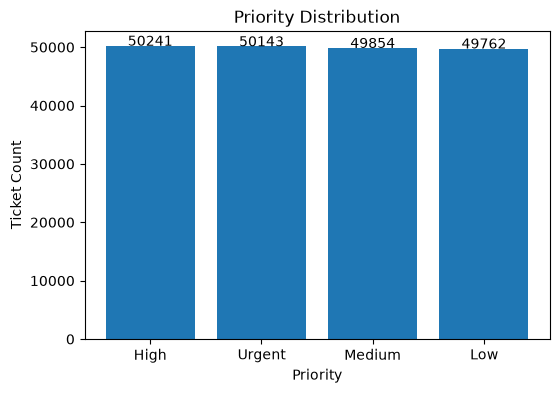

In [12]:
plt.figure(figsize=(6,4))

bars = plt.bar(priority_dist["Priority"], priority_dist["Ticket Count"])

for i in bars:
    plt.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha="center")

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Ticket Count")

plt.show()

In [13]:
print(f"Ticket Distribution w.r.t Category : \n\n{category_dist}")

Ticket Distribution w.r.t Category : 

                    Category  Ticket Count
0            Feature Request         20169
1  Subscription Cancellation         20096
2          Performance Issue         20074
3           Security Concern         20040
4                Login Issue         20002
5            Payment Problem         19997
6                 Bug Report         19981
7             Refund Request         19900
8            Data Sync Issue         19877
9         Account Suspension         19864


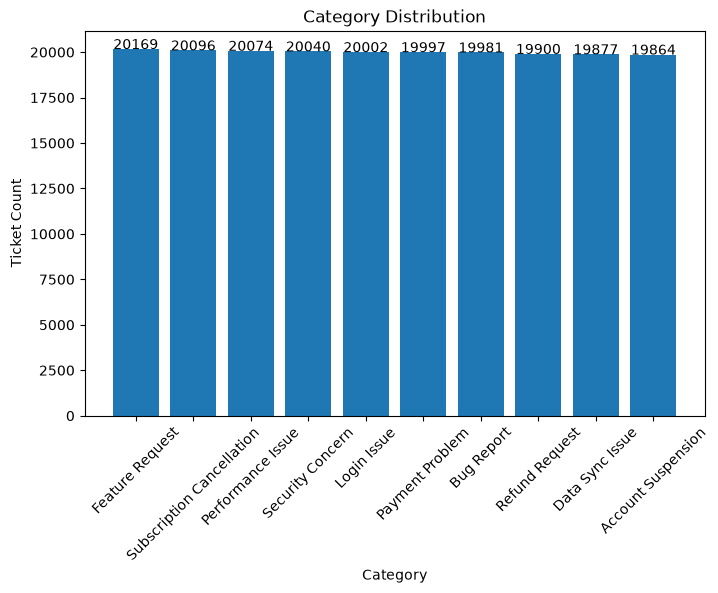

In [14]:
plt.figure(figsize=(8,5))

bars = plt.bar(category_dist["Category"], category_dist["Ticket Count"])

for i in bars:
    plt.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha="center")

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)

plt.show()

In [15]:
print(f"Ticket Distribution w.r.t Product : \n\n{product_dist}")

Ticket Distribution w.r.t Product : 

           Product Type  Ticket Count
0        Billing System         20111
1          CRM Platform         20097
2      E-commerce Store         20095
3         Cloud Storage         20056
4            Mobile App         20043
5   Analytics Dashboard         19974
6            Web Portal         19954
7       Payment Gateway         19952
8  Subscription Service         19883
9           API Service         19835


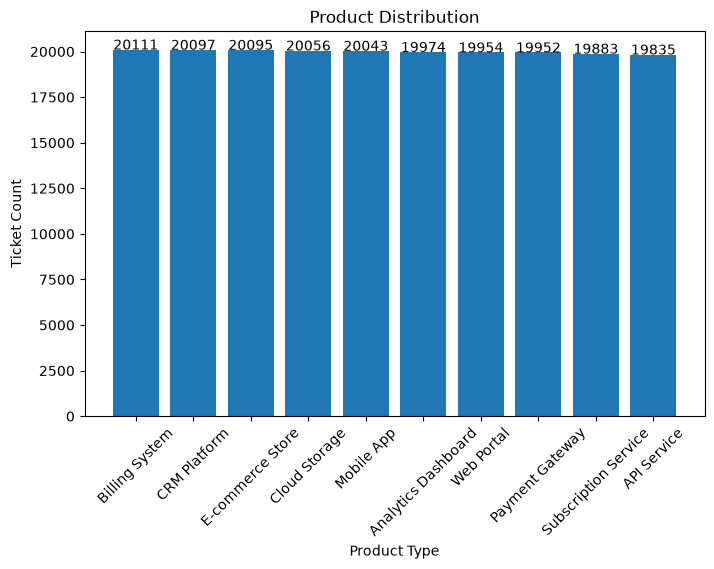

In [16]:
plt.figure(figsize=(8,5))

bars = plt.bar(product_dist["Product Type"], product_dist["Ticket Count"])

for i in bars:
    plt.text(i.get_x() + i.get_width()/2, i.get_height(), int(i.get_height()), ha="center")

plt.title("Product Distribution")
plt.xlabel("Product Type")
plt.ylabel("Ticket Count")
plt.xticks(rotation=45)

plt.show()

### 2. Module 2:- Data Cleaning and Feature Engineering

In [17]:
# Handling Missing Values & Cleaning Text

df['browser'] = df['browser'].fillna('Other/Not Applicable')

text_cols = df.select_dtypes(include=['object', 'str']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print(f"Total missing values remaining : {df.isnull().sum().sum()}")
print(f"\nBrowser column distribution after cleanup :\n{df['browser'].value_counts().head()}")

Total missing values remaining : 0

Browser column distribution after cleanup :
browser
Safari                  40156
Other/Not Applicable    40023
Firefox                 39983
Chrome                  39972
Edge                    39866
Name: count, dtype: int64


In [18]:
# converting date columns to proper datetime format
df['ticket_created_date'] = pd.to_datetime(df['ticket_created_date'], errors='coerce')
df['ticket_resolved_date'] = pd.to_datetime(df['ticket_resolved_date'], errors='coerce')

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\4225597222.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ticket_created_date'] = pd.to_datetime(df['ticket_created_date'], errors='coerce')
C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\4225597222.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['ticket_resolved_date'] = pd.to_datetime(df['ticket_resolved_date'], errors='coerce')


In [19]:
# extracting Resolution_Duration in hours
df['Resolution_Duration'] = (df['ticket_resolved_date'] - df['ticket_created_date']).dt.total_seconds() / 3600
df['Resolution_Duration'] = df['Resolution_Duration'].round(2)

In [20]:
# encoding priority into numerical scores for correlation and clustering later
priority_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Urgent': 4}
df['Priority_Score'] = df['priority'].map(priority_map)

In [21]:
# Categorize resolution efficiency into SLA performance buckets
def categorize_resolution(hours):
    if hours <= 24:
        return 'Fast (<24h)'
    elif hours <= 72:
        return 'Normal (24-72h)'
    else:
        return 'Slow (>72h)'

df['Performance_Bucket'] = df['Resolution_Duration'].apply(categorize_resolution)
    


In [22]:
# newly added columns
df[['priority', 'Priority_Score', 'ticket_created_date', 'ticket_resolved_date', 'Resolution_Duration','Performance_Bucket']].head()

,priority,Priority_Score,ticket_created_date,ticket_resolved_date,Resolution_Duration,Performance_Bucket
0,Urgent,4,2023-05-17,2023-05-20,72.0,Normal (24-72h)
1,Urgent,4,2024-01-06,2024-01-19,312.0,Slow (>72h)
2,Medium,2,2022-11-30,2022-12-05,120.0,Slow (>72h)
3,Medium,2,2024-03-21,2024-04-04,336.0,Slow (>72h)
4,High,3,2024-08-16,2024-08-24,192.0,Slow (>72h)


In [23]:
# saving the processed dataset 
clean_filename = 'processed_customer_support_tickets.csv'
df.to_csv(clean_filename, index=False)
print(f"\nCleaned dataset saved successfully as '{clean_filename}'")


Cleaned dataset saved successfully as 'processed_customer_support_tickets.csv'


In [24]:
df = pd.read_csv('processed_customer_support_tickets.csv')

## Milestone 2: Exploratory Visulaiztion and clustering

### 2. Module 3:- Exploratory Visualization 

In [25]:
# Setting global visual style for consistency
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\2059694958.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


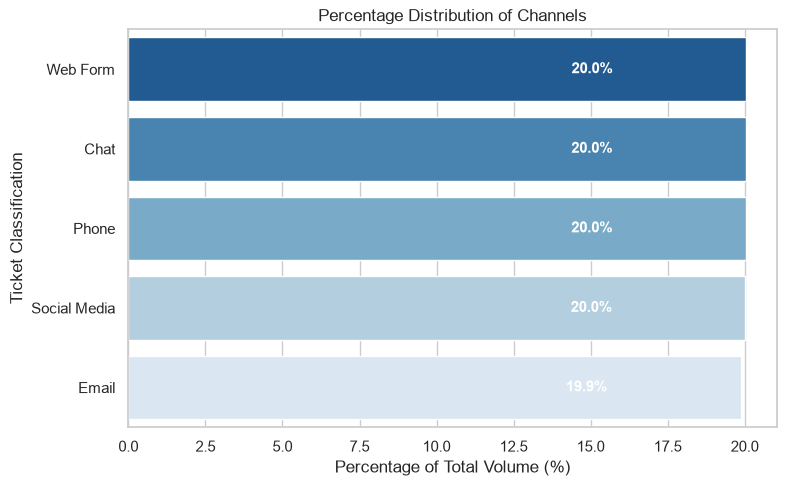

What it Shows: The proportional breakdown of incoming support volume by core classification 
(e.g., Incident, Service Request, Inquiry, or Inbound Channel).
How to Act on It: If repetitive Service Requests or general Inquiries account for more than 30% of your total volume, your self-service infrastructure is underperforming.
Divert these high-volume,low-complexity ticket types to automated portals and interactive FAQ bots to preserve human engineering bandwidth for critical incidents.


In [26]:
# 1. Ticket Type Distribution

plt.figure(figsize=(8, 5))
# Use 'ticket_type' if present, otherwise fallback to 'channel'
type_col = 'ticket_type' if 'ticket_type' in df.columns else 'channel'
type_counts = df[type_col].value_counts(normalize=True) * 100

ax = sns.barplot(
    x=type_counts.values, y=type_counts.index, palette='Blues_r', orient='h'
)
plt.title(f'Percentage Distribution of {type_col.replace("_", " ").title()}s')
plt.xlabel('Percentage of Total Volume (%)')
plt.ylabel('Ticket Classification')
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width() - 5, p.get_y() + p.get_height() / 2.),
        va='center',
        ha='center',
        color='white',
        fontweight='bold',
    )
plt.show()

print("""What it Shows: The proportional breakdown of incoming support volume by core classification 
(e.g., Incident, Service Request, Inquiry, or Inbound Channel).""")

print("""How to Act on It: If repetitive Service Requests or general Inquiries account for more than 30% of your total volume, your self-service infrastructure is underperforming.
Divert these high-volume,low-complexity ticket types to automated portals and interactive FAQ bots to preserve human engineering bandwidth for critical incidents.""")

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\1423440560.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


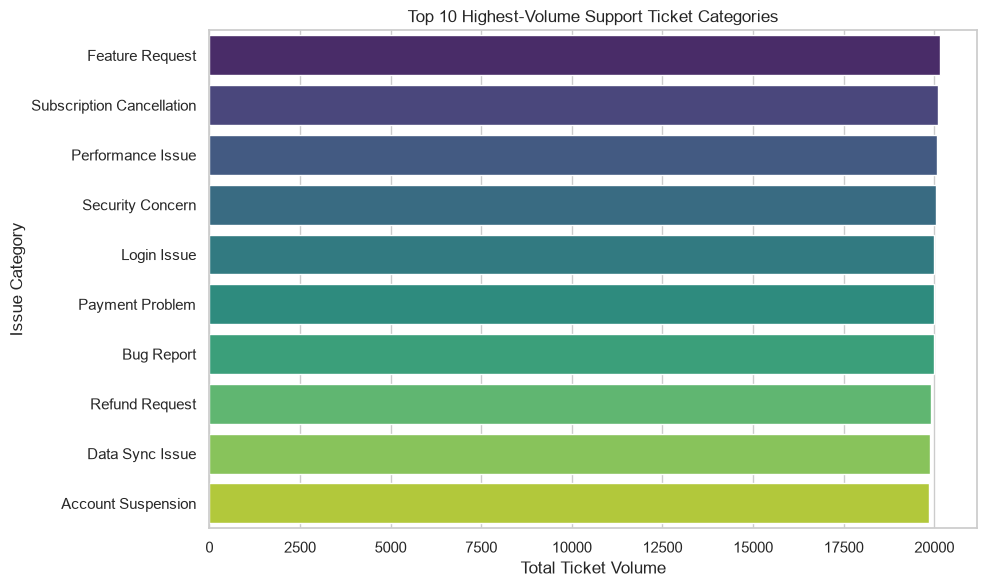

What it Shows: The absolute volume rank of specific technical and billing issues, isolating the primary reasons customers contact support.

How to Act on It: Cross-reference the top 3 categories with your product engineering roadmap. If a specific technical category (e.g., "Login Failure" or "Payment Gateway Error") consistently dominates the top of the list, push for a permanent root-cause engineering fix rather than continuing to scale headcount to treat the symptoms.


In [27]:
# 2. Top Categories

plt.figure(figsize=(10, 6))
top_categories = df['category'].value_counts().head(10)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette='viridis',
    orient='h',
)
plt.title('Top 10 Highest-Volume Support Ticket Categories')
plt.xlabel('Total Ticket Volume')
plt.ylabel('Issue Category')
plt.show()


print("""What it Shows: The absolute volume rank of specific technical and billing issues, isolating the primary reasons customers contact support.

How to Act on It: Cross-reference the top 3 categories with your product engineering roadmap. If a specific technical category (e.g., "Login Failure" or "Payment Gateway Error") consistently dominates the top of the list, push for a permanent root-cause engineering fix rather than continuing to scale headcount to treat the symptoms.""")

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\3534858884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='priority', data=df, order=priority_order, palette='Reds')


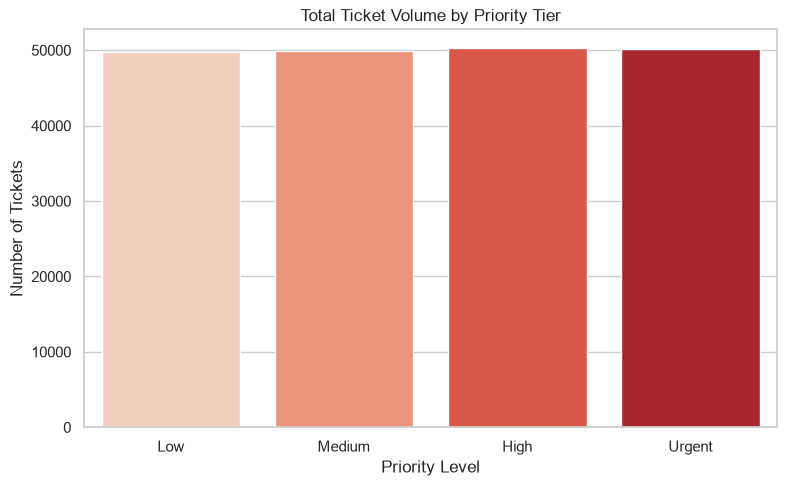

What it Shows: The overall severity grading of your incoming workload, demonstrating how internal triage rules classify customer emergencies.

How to Act on It: Audit for "priority inflation." In a balanced support ecosystem, Urgent and High priority tickets should together represent less than 20–25% of total volume. If agents or end-users are tagging more than a quarter of all tickets as Urgent, recalibrate your triage intake forms to require strict verification before an emergency tag is granted.


In [28]:
# 3. Tickets by Priority

plt.figure(figsize=(8, 5))
priority_order = ['Low', 'Medium', 'High', 'Urgent']
sns.countplot(x='priority', data=df, order=priority_order, palette='Reds')
plt.title('Total Ticket Volume by Priority Tier')
plt.xlabel('Priority Level')
plt.ylabel('Number of Tickets')
plt.show()


print("""What it Shows: The overall severity grading of your incoming workload, demonstrating how internal triage rules classify customer emergencies.

How to Act on It: Audit for "priority inflation." In a balanced support ecosystem, Urgent and High priority tickets should together represent less than 20–25% of total volume. If agents or end-users are tagging more than a quarter of all tickets as Urgent, recalibrate your triage intake forms to require strict verification before an emergency tag is granted.""")

<Figure size 1000x600 with 0 Axes>

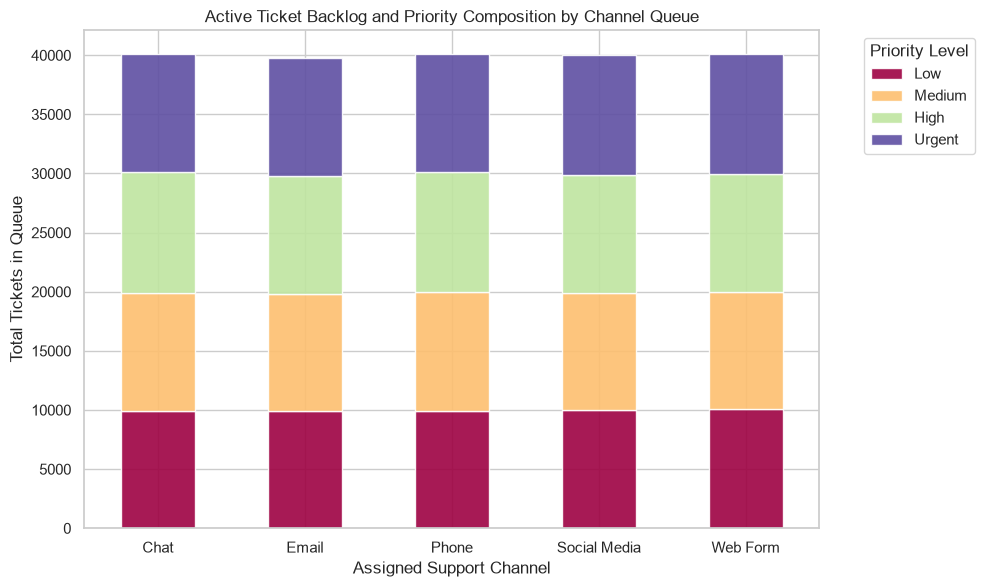

What it Shows: The actual workload concentration and priority severity stacked inside each specific support queue (or routing channel).

How to Act on It: Identify imbalanced queue routing. If a particular queue shows a disproportionately large red/orange stack (Urgent/High), immediately reallocate floating agents or Tier 2 engineers from lower-volume, low-priority queues to decompress the bottleneck before SLA breach limits are triggered.


In [29]:
# 4. Queue Visualization

plt.figure(figsize=(10, 6))
# Using 'queue' if present, otherwise fallback to 'channel' as proxy for routing tier
queue_col = 'queue' if 'queue' in df.columns else 'channel'
queue_priority = pd.crosstab(
    df[queue_col], df['priority']
)[['Low', 'Medium', 'High', 'Urgent']]

queue_priority.plot(
    kind='bar', stacked=True, colormap='Spectral', figsize=(10, 6), alpha=0.9
)
plt.title(
    f'Active Ticket Backlog and Priority Composition by {queue_col.title()} Queue'
)
plt.xlabel(f'Assigned Support {queue_col.title()}')
plt.ylabel('Total Tickets in Queue')
plt.legend(title='Priority Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

print("""What it Shows: The actual workload concentration and priority severity stacked inside each specific support queue (or routing channel).

How to Act on It: Identify imbalanced queue routing. If a particular queue shows a disproportionately large red/orange stack (Urgent/High), immediately reallocate floating agents or Tier 2 engineers from lower-volume, low-priority queues to decompress the bottleneck before SLA breach limits are triggered.""")

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\1574797611.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\1574797611.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


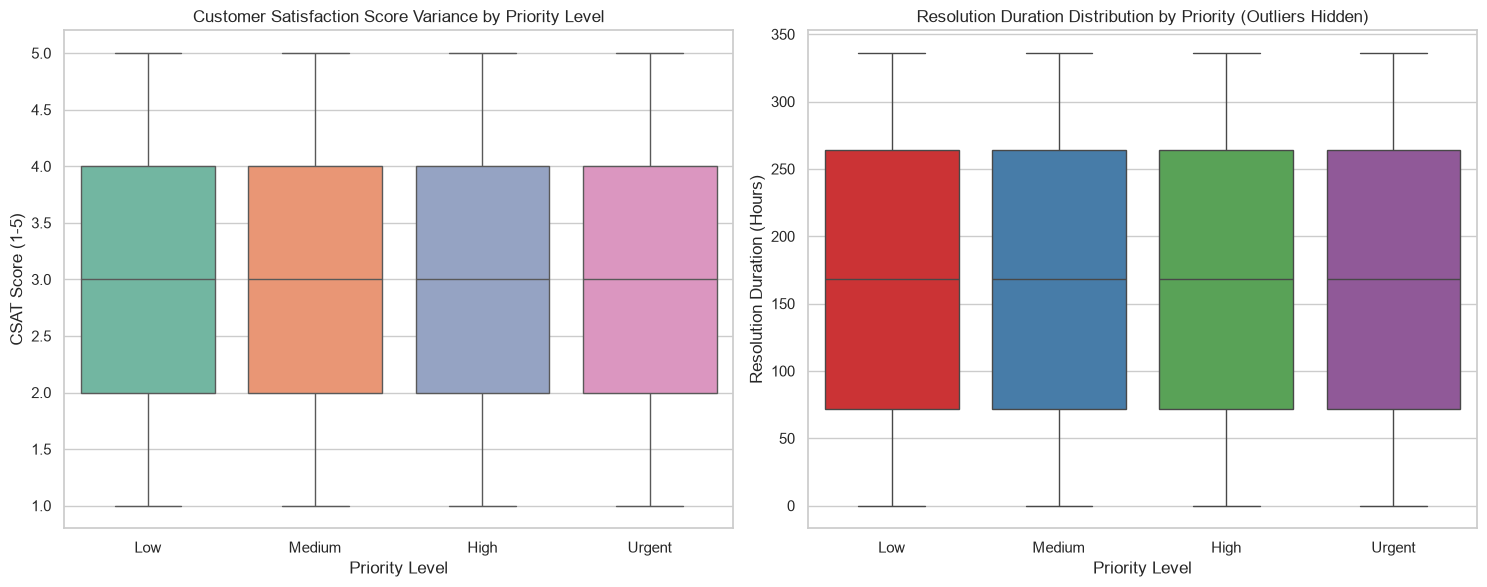

What it Shows: The exact median, interquartile range (IQR), and distributional skewness for customer satisfaction (left) and resolution speed across priority tiers (right).

How to Act on It: Check the interquartile range (the height of the colored box) on the right plot. If the box for Urgent priority has a wide vertical spread, your team's emergency response speed is inconsistent. Standardize emergency response procedures and assign a dedicated incident manager to ensure every single urgent ticket is resolved within a tight, highly predictable time window.


In [30]:
# 5. Boxplots (Outlier & Variance Analysis)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1: CSAT Variance across Priority Levels
sns.boxplot(
    x='priority',
    y='customer_satisfaction_score',
    data=df,
    ax=axes[0],
    order=['Low', 'Medium', 'High', 'Urgent'],
    palette='Set2',
)
axes[0].set_title('Customer Satisfaction Score Variance by Priority Level')
axes[0].set_xlabel('Priority Level')
axes[0].set_ylabel('CSAT Score (1-5)')

# Boxplot 2: Resolution Duration Variance across Priority Levels
sns.boxplot(
    x='priority',
    y='Resolution_Duration',
    data=df,
    ax=axes[1],
    order=['Low', 'Medium', 'High', 'Urgent'],
    palette='Set1',
    showfliers=False,  # Hides extreme outliers to keep the median/quartile box legible
)
axes[1].set_title(
    'Resolution Duration Distribution by Priority (Outliers Hidden)'
)
axes[1].set_xlabel('Priority Level')
axes[1].set_ylabel('Resolution Duration (Hours)')

plt.show()


print("""What it Shows: The exact median, interquartile range (IQR), and distributional skewness for customer satisfaction (left) and resolution speed across priority tiers (right).

How to Act on It: Check the interquartile range (the height of the colored box) on the right plot. If the box for Urgent priority has a wide vertical spread, your team's emergency response speed is inconsistent. Standardize emergency response procedures and assign a dedicated incident manager to ensure every single urgent ticket is resolved within a tight, highly predictable time window.""")

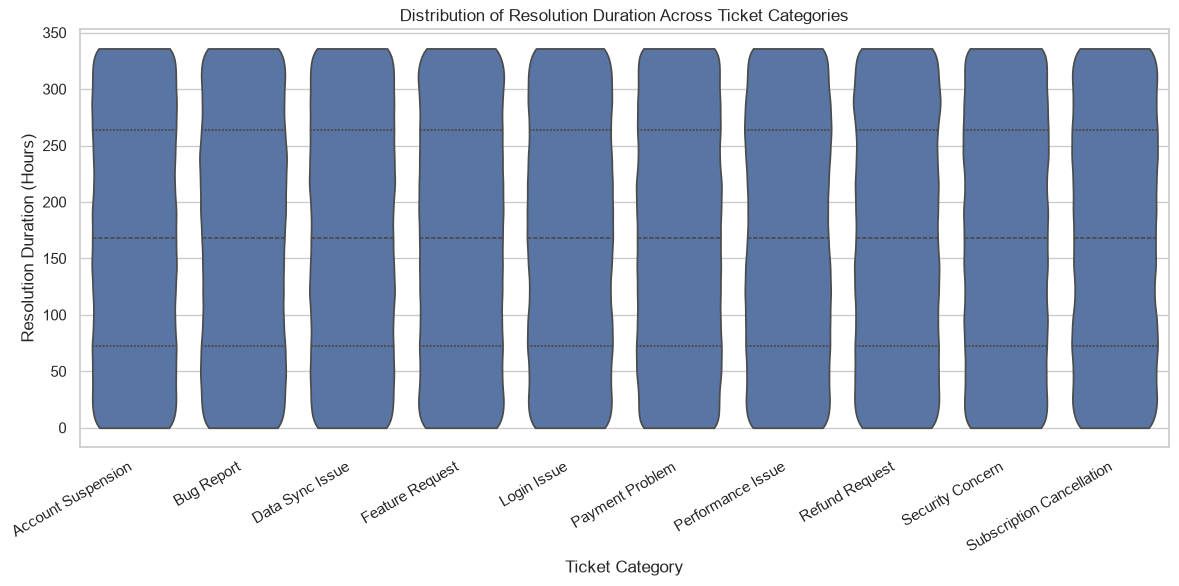

# Rationale: Identifies which problem categories suffer from the widest variance and longest delays.


In [31]:
# 6. Resolution Duration Distribution by Issue Category


plt.figure(figsize=(12, 6))
order_cat = (
    df.groupby('category')['Resolution_Duration']
    .median()
    .sort_values(ascending=False)
    .index
)
sns.violinplot(
    x='category',
    y='Resolution_Duration',
    data=df,
    order=order_cat,
    inner='quartile',
    cut=0,
)
plt.title('Distribution of Resolution Duration Across Ticket Categories')
plt.xlabel('Ticket Category')
plt.ylabel('Resolution Duration (Hours)')
plt.xticks(rotation=30, ha='right')
plt.show()

print("# Rationale: Identifies which problem categories suffer from the widest variance and longest delays.")

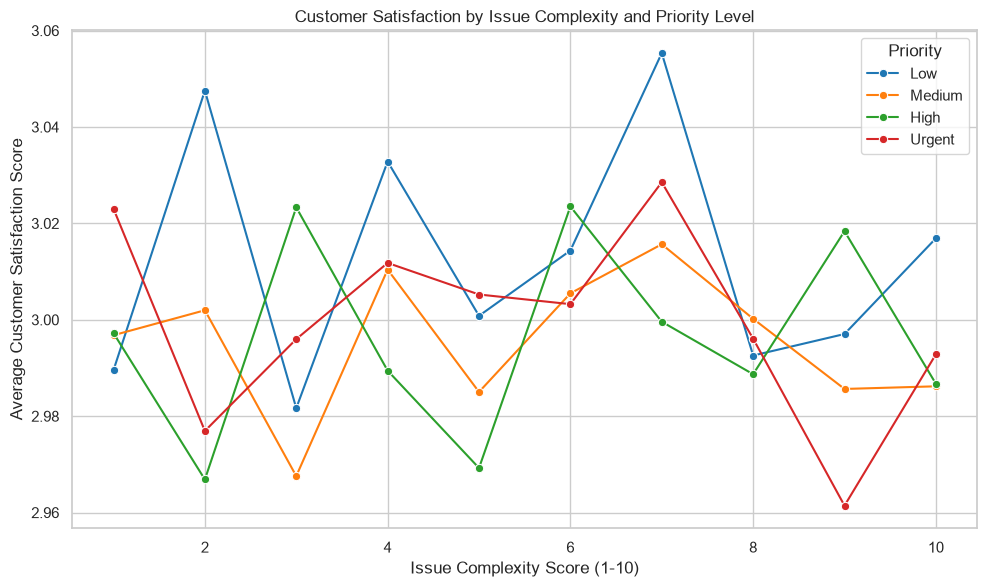

# Rationale: Evaluates whether high-priority status mitigates frustration on complex issues.


In [32]:
# 7. Impact of Issue Complexity on CSAT across Priority Levels


plt.figure(figsize=(10, 6))
sns.lineplot(
    x='issue_complexity_score',
    y='customer_satisfaction_score',
    hue='priority',
    hue_order=['Low', 'Medium', 'High', 'Urgent'],
    data=df,
    marker='o',
    errorbar=None,
    palette='tab10',
)
plt.title('Customer Satisfaction by Issue Complexity and Priority Level')
plt.xlabel('Issue Complexity Score (1-10)')
plt.ylabel('Average Customer Satisfaction Score')
plt.legend(title='Priority')
plt.show()

print("# Rationale: Evaluates whether high-priority status mitigates frustration on complex issues.")

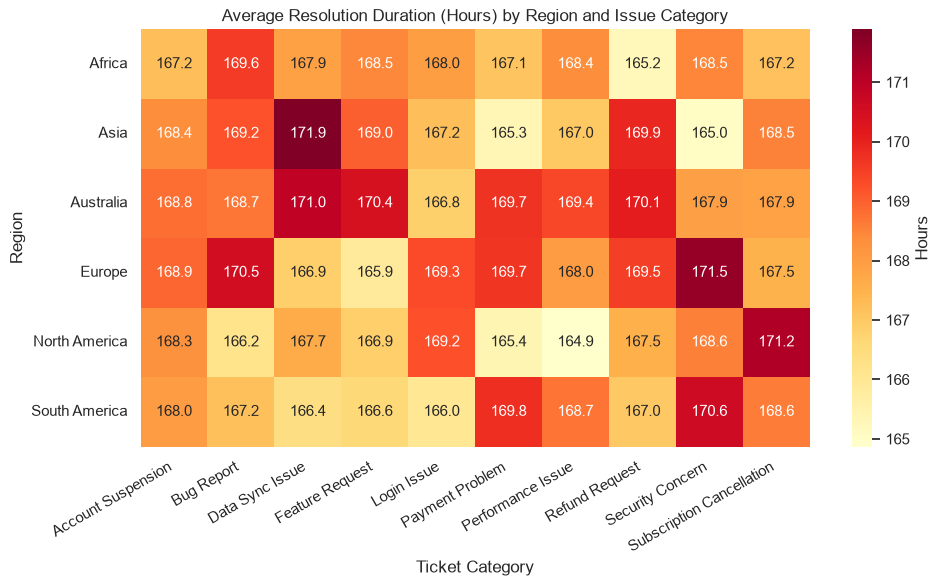

# Rationale: Identifies regional concentrations of specific technical or billing issues.


In [33]:
# 8. Geographic & Categorical Bottleneck Heatmap


plt.figure(figsize=(10, 6))
region_cat_pivot = df.pivot_table(
    index='region',
    columns='category',
    values='Resolution_Duration',
    aggfunc='mean',
)
sns.heatmap(
    region_cat_pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Hours'}
)
plt.title('Average Resolution Duration (Hours) by Region and Issue Category')
plt.ylabel('Region')
plt.xlabel('Ticket Category')
plt.xticks(rotation=30, ha='right')
plt.show()

print("# Rationale: Identifies regional concentrations of specific technical or billing issues.")

### Module 4:- Similarity and Cluster Insights  

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select features for clustering
cluster_features = [
    'Resolution_Duration',
    'issue_complexity_score',
    'customer_satisfaction_score',
    'Priority_Score',
]
X = df[cluster_features].dropna()

In [35]:
# 2. Standardize data (Z-score scaling) so features contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
# 3. Fit K-Means Model (k=4 provides clean operational segmentation)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [37]:
# 4. Profile the generated clusters
cluster_profile = df.groupby('Cluster')[cluster_features].mean()
cluster_profile['Ticket_Volume'] = df.groupby('Cluster')['ticket_id'].count()
cluster_profile['Percentage'] = (
    cluster_profile['Ticket_Volume'] / len(df)
) * 100
# Display the finalized Cluster Profile Table
print("=== OPERATIONAL CLUSTER PROFILES ===")
display(cluster_profile.round(2))

=== OPERATIONAL CLUSTER PROFILES ===


,Resolution_Duration,issue_complexity_score,customer_satisfaction_score,Priority_Score,Ticket_Volume,Percentage
Cluster,,,,,,
0,167.84,7.81,3.02,1.42,51062,25.53
1,268.66,3.16,3.04,2.55,49141,24.57
2,165.04,7.84,3.00,3.57,50652,25.33
3,71.40,3.03,2.94,2.48,49145,24.57


C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\65095696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


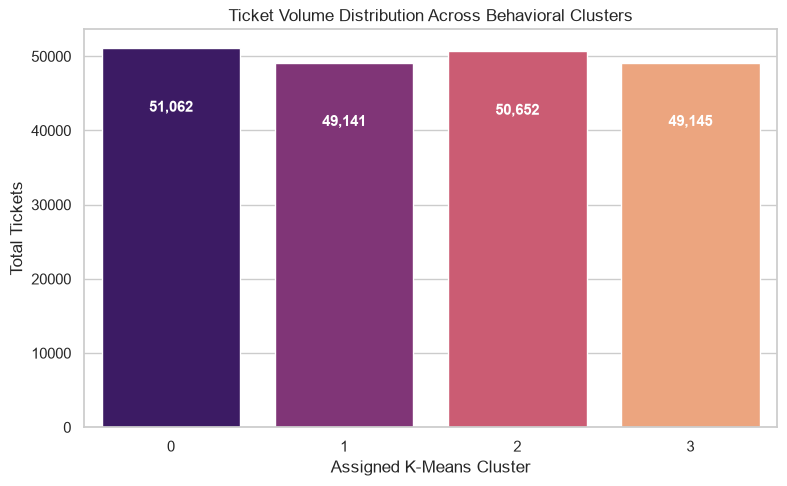

What it Shows: The exact volume distribution across your 4 engineered K-Means problem clusters, revealing whether your queue is dominated by quick wins or complex bottlenecks.

How to Act on It: If your high-complexity or slow-burn clusters collectively represent more than 30% of your total volume, your operational pipeline is clogged. Establish dedicated specialized squads to clear backlog clusters so generalist Tier 1 agents can focus exclusively on maintaining fast turnaround times for routine inquiries.


In [38]:
# 9. Clusters by Frequency

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    x='Cluster',
    data=df,
    palette='magma',
    order=sorted(df['Cluster'].unique()),
)
plt.title('Ticket Volume Distribution Across Behavioral Clusters')
plt.xlabel('Assigned K-Means Cluster')
plt.ylabel('Total Tickets')
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height() - 8000),
        va='center',
        ha='center',
        color='white',
        fontweight='bold',
    )
plt.show()

print("""What it Shows: The exact volume distribution across your 4 engineered K-Means problem clusters, revealing whether your queue is dominated by quick wins or complex bottlenecks.

How to Act on It: If your high-complexity or slow-burn clusters collectively represent more than 30% of your total volume, your operational pipeline is clogged. Establish dedicated specialized squads to clear backlog clusters so generalist Tier 1 agents can focus exclusively on maintaining fast turnaround times for routine inquiries.""")

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\4069775574.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


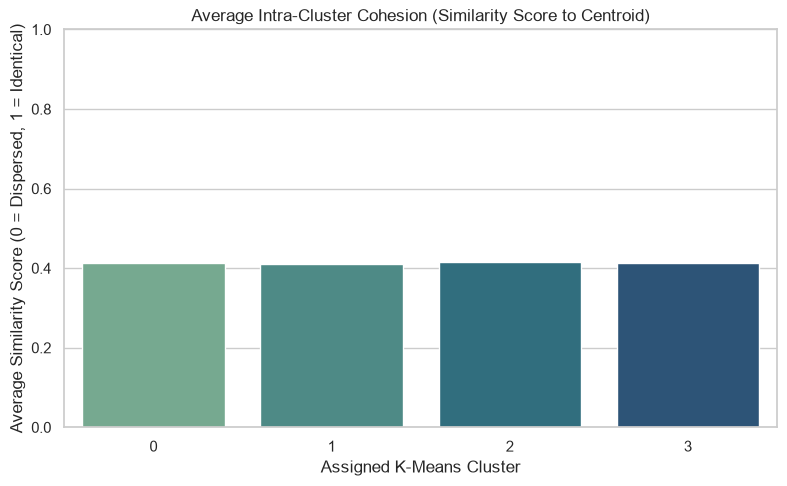

What it Shows: How tightly grouped or homogeneous the behaviors are within each K-Means cluster. A high score (>0.5) proves the tickets in that cluster share nearly identical operational characteristics.

How to Act on It: Use the highest-similarity cluster to deploy standardized automated workflows. If a cluster demonstrates high similarity, those tickets behave almost identically every time. Write a strict automated script or LLM agent to handle that entire cluster automatically, knowing with high mathematical confidence that edge cases won't disrupt the flow.


In [39]:
# 10. Average Similarity Score Within Clusters

# Calculate distance from each ticket to its assigned cluster centroid
distances = np.linalg.norm(
    X_scaled - kmeans.cluster_centers_[df['Cluster']], axis=1
)
# Convert Euclidean distance to a bounded similarity score between 0 and 1
df['Similarity_Score'] = 1 / (1 + distances)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Cluster',
    y='Similarity_Score',
    data=df,
    palette='crest',
    errorbar=None,
)
plt.title('Average Intra-Cluster Cohesion (Similarity Score to Centroid)')
plt.xlabel('Assigned K-Means Cluster')
plt.ylabel('Average Similarity Score (0 = Dispersed, 1 = Identical)')
plt.ylim(0, 1.0)
plt.show()

print("""What it Shows: How tightly grouped or homogeneous the behaviors are within each K-Means cluster. A high score (>0.5) proves the tickets in that cluster share nearly identical operational characteristics.

How to Act on It: Use the highest-similarity cluster to deploy standardized automated workflows. If a cluster demonstrates high similarity, those tickets behave almost identically every time. Write a strict automated script or LLM agent to handle that entire cluster automatically, knowing with high mathematical confidence that edge cases won't disrupt the flow.""")

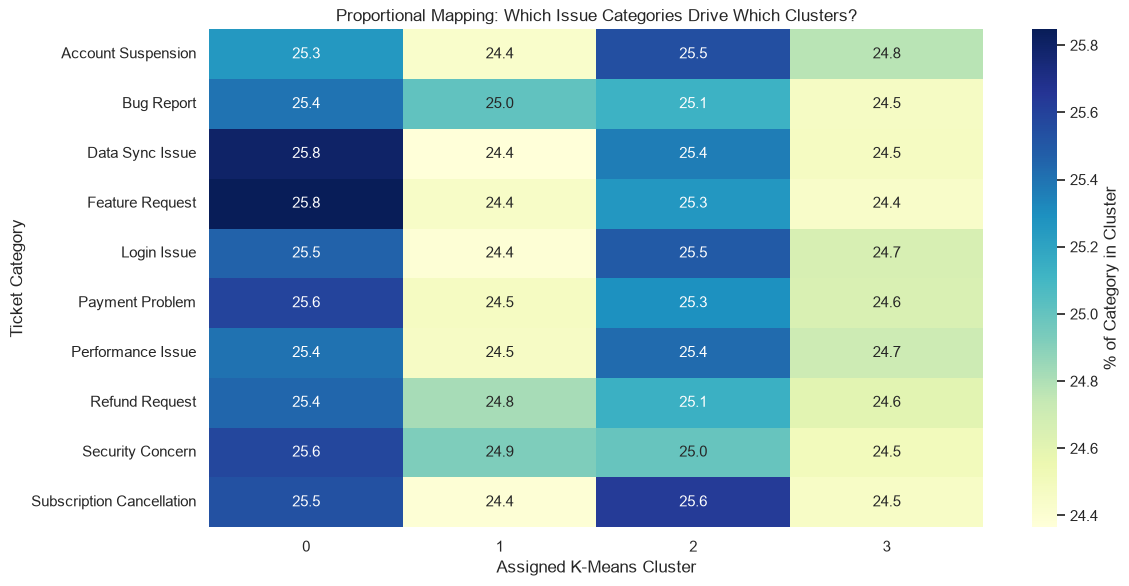

What it Shows: A cross-tabular heatmap revealing exactly which product categories map to your high-risk operational clusters.

How to Act on It: Look for dark concentration squares intersecting your highest-risk clusters. If you see that 60% of all "Database Sync Failures" land directly inside your most complex bottleneck cluster, you have isolated the structural cause of your team's longest resolution delays. Mandate advanced technical training for support agents specifically on that single product category.


In [40]:
# 11. Compare Cluster Size vs. Issue Type

plt.figure(figsize=(12, 6))
# Calculate the percentage of each issue category that falls into each cluster
cluster_cat_pivot = pd.crosstab(
    df['category'], df['Cluster'], normalize='index'
) * 100

sns.heatmap(
    cluster_cat_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': '% of Category in Cluster'},
)
plt.title('Proportional Mapping: Which Issue Categories Drive Which Clusters?')
plt.xlabel('Assigned K-Means Cluster')
plt.ylabel('Ticket Category')
plt.show()

print("""What it Shows: A cross-tabular heatmap revealing exactly which product categories map to your high-risk operational clusters.

How to Act on It: Look for dark concentration squares intersecting your highest-risk clusters. If you see that 60% of all "Database Sync Failures" land directly inside your most complex bottleneck cluster, you have isolated the structural cause of your team's longest resolution delays. Mandate advanced technical training for support agents specifically on that single product category.""")

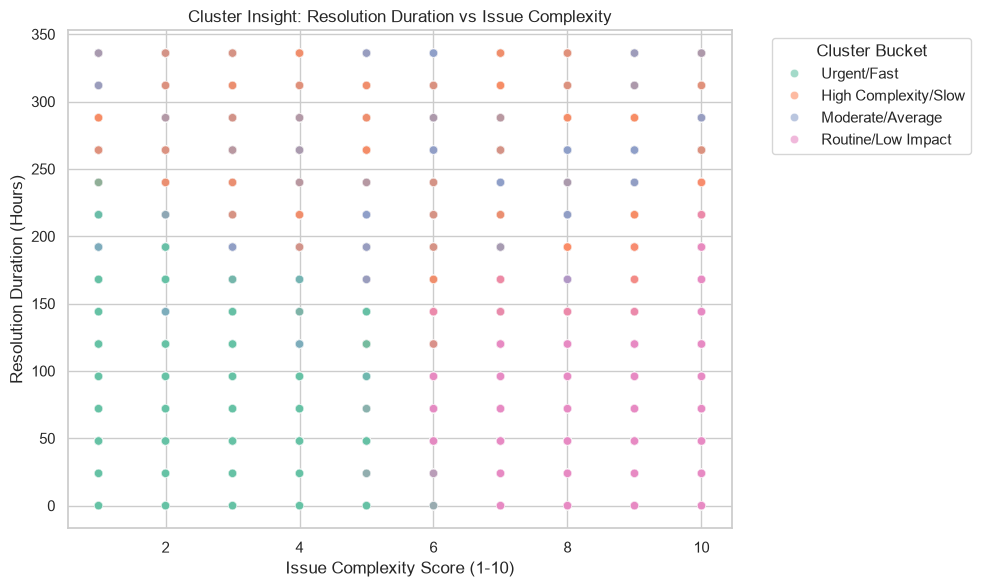

What it Shows: How tickets naturally group together based on priority, complexity, and how long they take to resolve.
How to Act on It: Focus engineering and triage efforts on the 'High Complexity/Slow' cluster to detect systemic workflow bottlenecks.


In [41]:
# Select numerical features for clustering
cluster_features = df[['Resolution_Duration', 'Priority_Score', 'issue_complexity_score']].dropna()

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(scaled_features)

# Map numeric IDs to descriptive Cluster Names based on expected operational buckets
cluster_mapping = {
    0: 'Routine/Low Impact', 
    1: 'High Complexity/Slow', 
    2: 'Urgent/Fast', 
    3: 'Moderate/Average'
}
df['Cluster_Name'] = df['Cluster_ID'].map(cluster_mapping)

# Visualize Cluster Performance vs. Complexity
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='issue_complexity_score', 
    y='Resolution_Duration', 
    hue='Cluster_Name', 
    palette='Set2',
    alpha=0.6
)
plt.title('Cluster Insight: Resolution Duration vs Issue Complexity')
plt.xlabel('Issue Complexity Score (1-10)')
plt.ylabel('Resolution Duration (Hours)')
plt.legend(title='Cluster Bucket', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("""What it Shows: How tickets naturally group together based on priority, complexity, and how long they take to resolve.
How to Act on It: Focus engineering and triage efforts on the 'High Complexity/Slow' cluster to detect systemic workflow bottlenecks.""")

## Milestone 3: Performance trend analysis and Geographic and category-level insights

### Module 5:- Performance Trend Analysis

In [42]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,preferred_contact_time,issue_complexity_score,customer_segment,Resolution_Duration,Priority_Score,Performance_Bucket,Cluster,Similarity_Score,Cluster_ID,Cluster_Name
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,Afternoon,4,Small Business,72.0,4,Normal (24-72h),3,0.331115,2,Urgent/Fast
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,Afternoon,2,Small Business,312.0,4,Slow (>72h),1,0.334493,1,High Complexity/Slow
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,Morning,4,Corporate,120.0,2,Slow (>72h),3,0.380082,2,Urgent/Fast
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,Afternoon,7,Corporate,336.0,2,Slow (>72h),1,0.370691,3,Moderate/Average
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,Evening,3,Corporate,192.0,3,Slow (>72h),1,0.381604,2,Urgent/Fast


In [43]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment', 'Resolution_Duration',
       'Priority_Score', 'Performance_Bucket', 'Cluster', 'Similarity_Score',
       'Cluster_ID', 'Cluster_Name'],
      dtype='str')

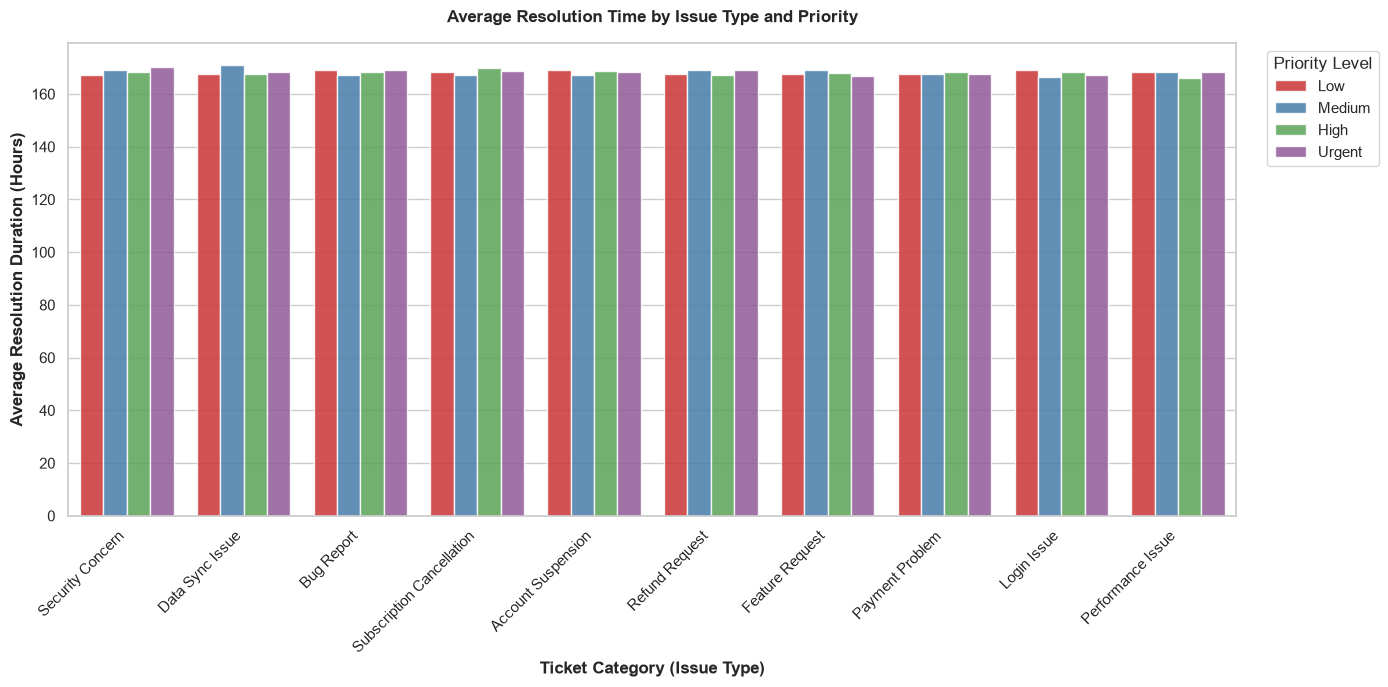

In [44]:
# Analyze average resolution times by priority and type 


# 1. Determine the order of categories based on overall average resolution time for a sorted x-axis
category_order = df.groupby('category')['Resolution_Duration'].mean().sort_values(ascending=False).index

# 2. Create the grouped bar plot
plt.figure(figsize=(14, 7))
sns.barplot(
    x='category', 
    y='Resolution_Duration', 
    hue='priority', 
    data=df, 
    order=category_order,
    hue_order=['Low', 'Medium', 'High', 'Urgent'],
    palette='Set1',
    errorbar=None,
    alpha=0.85
)

# 3. Format the visual elements
plt.title('Average Resolution Time by Issue Type and Priority', fontweight='bold', pad=15)
plt.xlabel('Ticket Category (Issue Type)', fontweight='bold')
plt.ylabel('Average Resolution Duration (Hours)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Priority Level', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()

C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\1204825699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


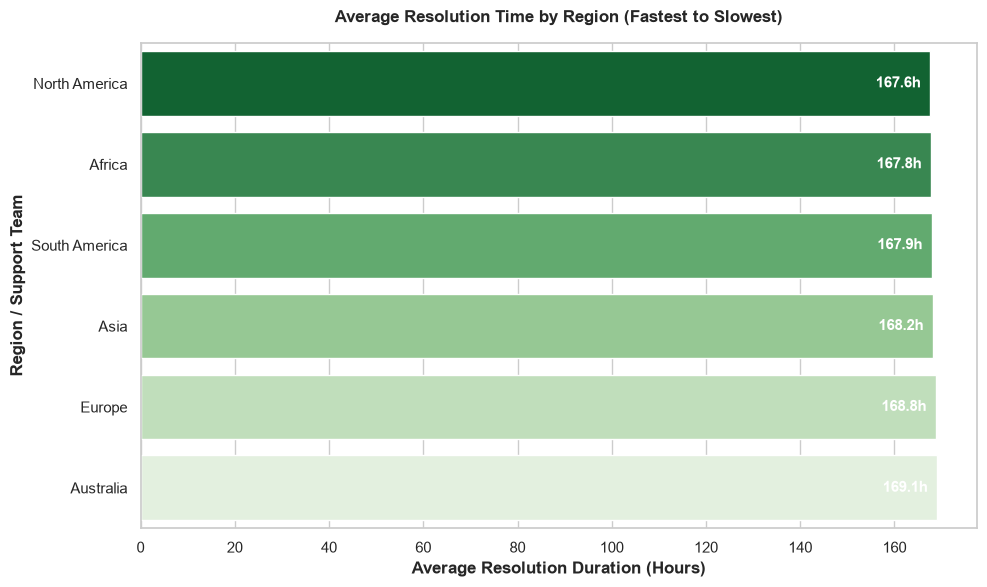

In [45]:
# Determine which countries or teams handle tickets fastest 

# 1. Group by region and calculate the average resolution duration
# Sorting ascending=True so the fastest regions appear at the top of the chart
region_performance = df.groupby('region')['Resolution_Duration'].mean().sort_values(ascending=True)

# 2. Create a horizontal bar plot for clear ranking
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=region_performance.values, 
    y=region_performance.index, 
    palette='Greens_r' # Darker green implies faster/better performance
)

# 3. Add data labels inside the bars for quick readability
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}h', 
        (p.get_width() - 2, p.get_y() + p.get_height() / 2.), 
        va='center', 
        ha='right', 
        color='white', 
        fontweight='bold'
    )

# 4. Format the visual elements
plt.title('Average Resolution Time by Region (Fastest to Slowest)', fontweight='bold', pad=15)
plt.xlabel('Average Resolution Duration (Hours)', fontweight='bold')
plt.ylabel('Region / Support Team', fontweight='bold')

plt.show()


C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\1468612643.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


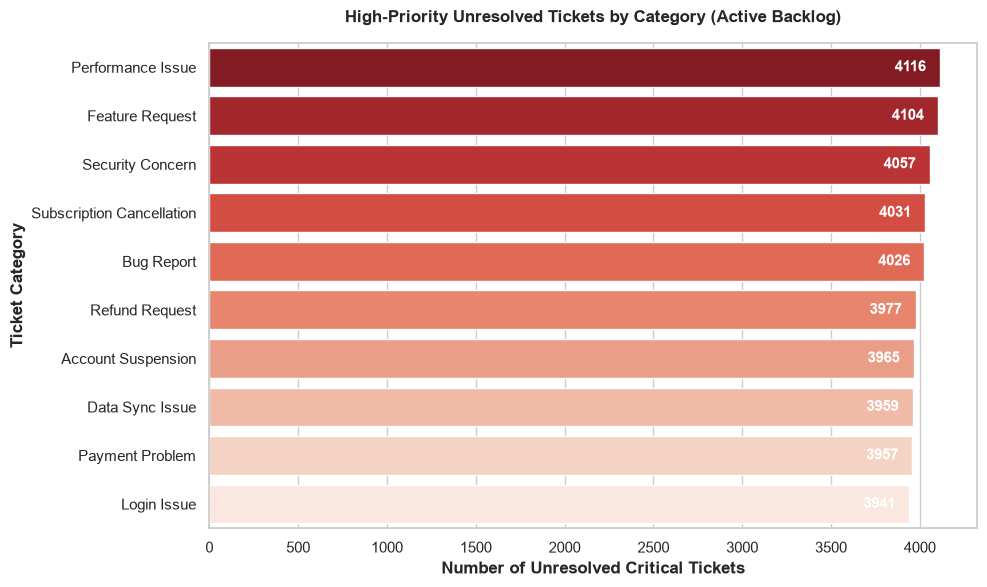

In [46]:
# Identify high-priority unresolved issues

# 1. Filter for High-Priority Unresolved Issues
# Adjust the status list ('Open', 'Pending', 'In Progress') based on your exact dataset values
unresolved_statuses = ['Open', 'Pending', 'In Progress'] 
high_priorities = ['High', 'Urgent']

unresolved_critical = df[
    (df['status'].isin(unresolved_statuses)) & 
    (df['priority'].isin(high_priorities))
]

# 2. Summarize the backlog by Category
critical_backlog = unresolved_critical['category'].value_counts().reset_index()
critical_backlog.columns = ['Category', 'Unresolved_Count']

# 3. Create a horizontal bar plot to highlight the biggest risks
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Unresolved_Count', 
    y='Category', 
    data=critical_backlog, 
    palette='Reds_r' # Dark red highlights the highest volume of critical issues
)

# 4. Add data labels for exact ticket counts (Corrected with proper x, y tuple)
for p in ax.patches:
    width = p.get_width()
    
   
    if pd.isna(width) or width == 0:
        continue
        
    ax.annotate(
        f'{int(width)}', 
        (
            width - max(1, width * 0.02),    # X-coordinate
            p.get_y() + p.get_height() / 2.  # Y-coordinate
        ), 
        va='center', 
        ha='right', 
        color='white', 
        fontweight='bold'
    )

# 5. Format visual elements
plt.title('High-Priority Unresolved Tickets by Category (Active Backlog)', fontweight='bold', pad=15)
plt.xlabel('Number of Unresolved Critical Tickets', fontweight='bold')
plt.ylabel('Ticket Category', fontweight='bold')

plt.show()



### Module 6:- Geographic and Category-Level Insights

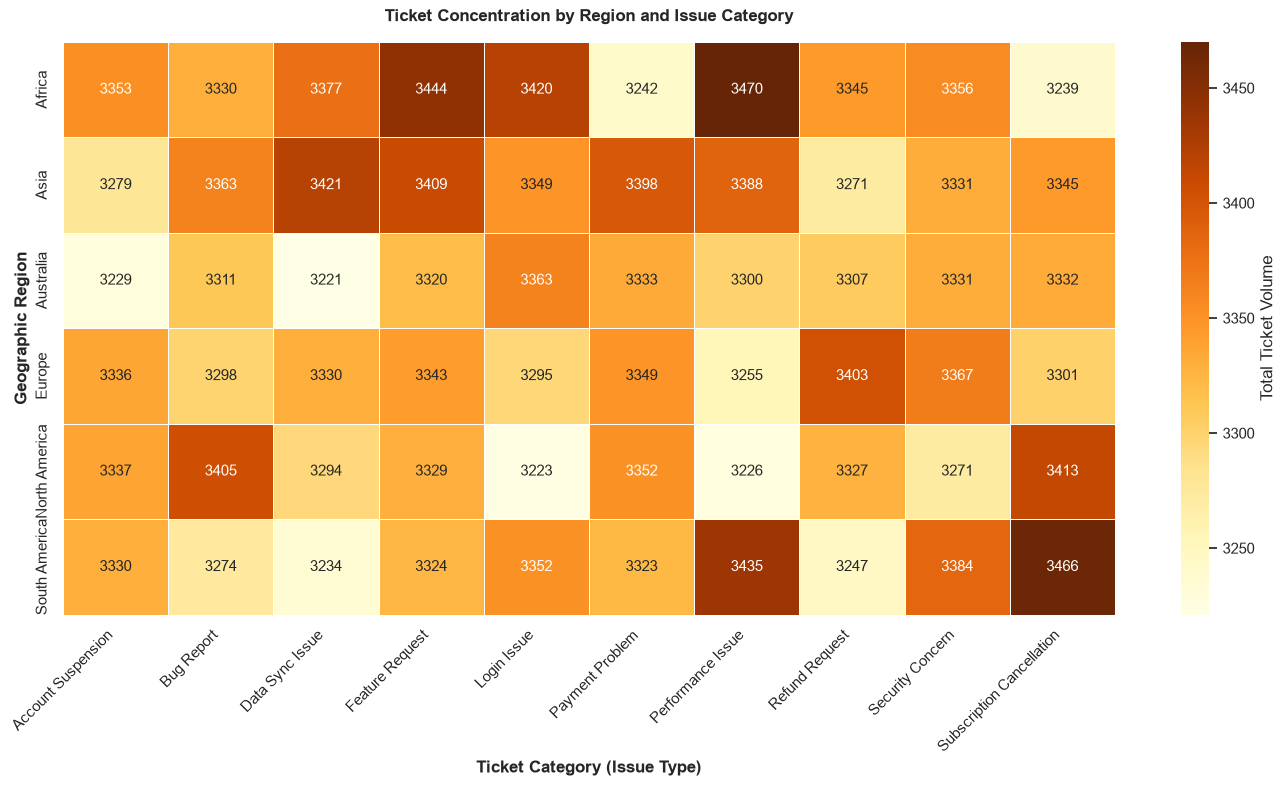

In [47]:
# 1. Create a cross-tabulation matrix calculating total ticket volume by Region and Category
region_category_matrix = pd.crosstab(df['region'], df['category'])

# 2. Create the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    region_category_matrix, 
    annot=True, 
    fmt="d",          
    cmap="YlOrBr",    
    cbar_kws={'label': 'Total Ticket Volume'},
    linewidths=0.5
)

# 3. Format visual elements
plt.title('Ticket Concentration by Region and Issue Category', fontweight='bold', pad=15)
plt.xlabel('Ticket Category (Issue Type)', fontweight='bold')
plt.ylabel('Geographic Region', fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.show()

In [48]:
# 1. Aggregate ticket volume by Region and Issue Category
geo_data = df.groupby(['region', 'category']).size().reset_index(name='Ticket_Volume')

# 2. Create a geographic mapping dictionary
# NOTE: Update the keys in this dictionary to match the exact unique values in your df['region']
coordinate_mapping = {
    'North America': {'lat': 37.0902, 'lon': -95.7129},
    'United States': {'lat': 37.0902, 'lon': -95.7129},
    'Europe': {'lat': 51.1657, 'lon': 10.4515},
    'United Kingdom': {'lat': 55.3781, 'lon': -3.4360},
    'Asia': {'lat': 34.0479, 'lon': 100.6197},
    'India': {'lat': 20.5937, 'lon': 78.9629},
    'South America': {'lat': -14.2350, 'lon': -51.9253},
    'Australia': {'lat': -25.2744, 'lon': 133.7751},
    'Africa': {'lat': -8.7832, 'lon': -55.4915}
}

# 3. Apply coordinates to the dataframe (Defaults to 0.0 if region is not in dictionary)
geo_data['latitude'] = geo_data['region'].apply(lambda x: coordinate_mapping.get(x, {}).get('lat', 0.0))
geo_data['longitude'] = geo_data['region'].apply(lambda x: coordinate_mapping.get(x, {}).get('lon', 0.0))

# 4. Generate the Interactive Geographic Scatter Map
fig = px.scatter_geo(
    geo_data,
    lat='latitude',
    lon='longitude',
    color='category',
    size='Ticket_Volume',
    hover_name='region',
    projection='natural earth',
    title='Geographic Distribution of Issue Categories',
    opacity=0.7,
    size_max=40,
    template='plotly_white'
)

# 5. Format visual layout
fig.update_layout(
    legend_title_text='Issue Category',
    title_font_size=18,
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

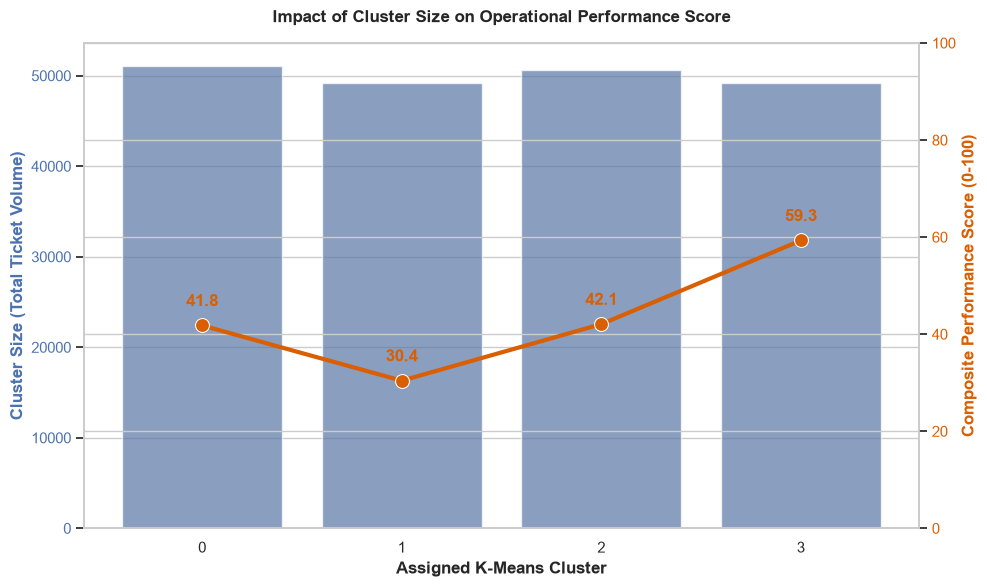

In [49]:
# 1. Define SLA Compliance (Resolutions under 72 hours are considered compliant)
df['SLA_Compliant'] = df['Resolution_Duration'] <= 72

# 2. Group by Cluster to calculate Size and Performance Metrics
cluster_metrics = df.groupby('Cluster').agg(
    Cluster_Size=('ticket_id', 'count'),
    SLA_Compliance_Rate=('SLA_Compliant', lambda x: x.mean() * 100),
    Avg_CSAT=('customer_satisfaction_score', 'mean')
).reset_index()

# 3. Calculate an aggregate Performance Score (0 to 100 scale)
# Averages the SLA Compliance % and the CSAT % (CSAT / 5 * 100)
cluster_metrics['Performance_Score'] = (
    cluster_metrics['SLA_Compliance_Rate'] + (cluster_metrics['Avg_CSAT'] / 5 * 100)
) / 2

# 4. Create a Dual-Axis Visualization
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Cluster Size (Ticket Volume)
sns.barplot(
    x='Cluster', 
    y='Cluster_Size', 
    data=cluster_metrics, 
    color='#4c72b0', 
    ax=ax1, 
    alpha=0.7
)
ax1.set_xlabel('Assigned K-Means Cluster', fontweight='bold')
ax1.set_ylabel('Cluster Size (Total Ticket Volume)', color='#4c72b0', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4c72b0')

# Line chart for Performance Score
ax2 = ax1.twinx()
sns.lineplot(
    x='Cluster', 
    y='Performance_Score', 
    data=cluster_metrics, 
    ax=ax2, 
    color='#d95f02', 
    marker='o', 
    linewidth=3, 
    markersize=10
)
ax2.set_ylabel('Composite Performance Score (0-100)', color='#d95f02', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='#d95f02')

# Annotate the Performance Score data points
for i, row in cluster_metrics.iterrows():
    ax2.annotate(
        f"{row['Performance_Score']:.1f}", 
        (i, row['Performance_Score'] + 4), 
        ha='center', 
        color='#d95f02', 
        fontweight='bold',
        fontsize=12
    )

plt.title('Impact of Cluster Size on Operational Performance Score', fontweight='bold', pad=15)
plt.show()


--- GLOBAL PERFORMANCE METRICS SUMMARY ---


,Key Performance Indicator (KPI),Current Value
0,Total Tickets Processed,"200,000"
1,Global Average CSAT (1-5),3.00
2,Global Average Resolution Time (Hours),168.21
3,Overall SLA Compliance Rate (%),26.71%
4,Active Critical Backlog (Unresolved High/Urgent),"40,133"


C:\Users\shresth prakash\AppData\Local\Temp\ipykernel_8916\468439618.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


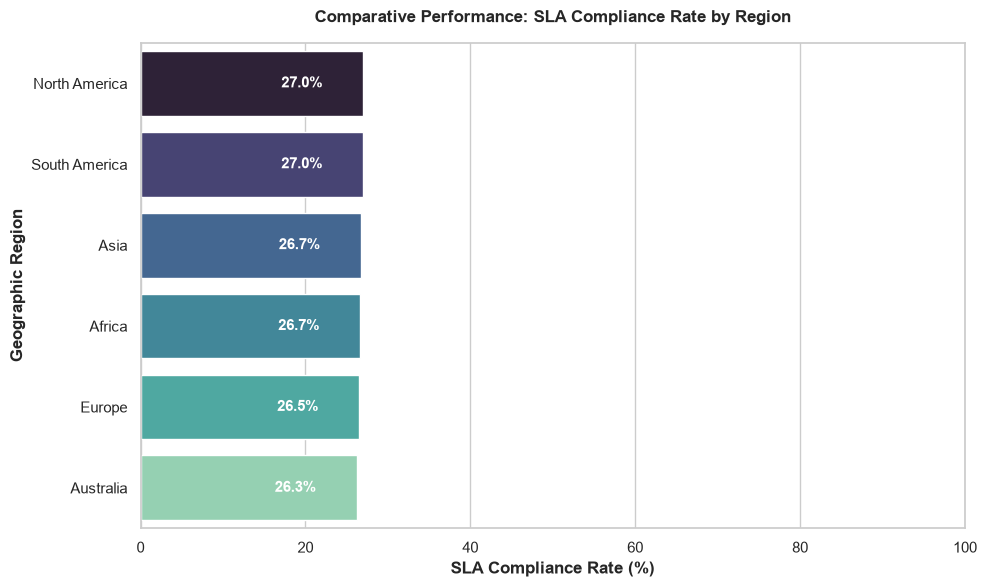

In [50]:
# 1. Generate Performance Metrics Summary Table
print("--- GLOBAL PERFORMANCE METRICS SUMMARY ---")
sla_limit = 72 # Assuming 72 hours as the SLA benchmark

summary_metrics = pd.DataFrame({
    'Key Performance Indicator (KPI)': [
        'Total Tickets Processed',
        'Global Average CSAT (1-5)',
        'Global Average Resolution Time (Hours)',
        'Overall SLA Compliance Rate (%)',
        'Active Critical Backlog (Unresolved High/Urgent)'
    ],
    'Current Value': [
        f"{len(df):,}",
        f"{df['customer_satisfaction_score'].mean():.2f}",
        f"{df['Resolution_Duration'].mean():.2f}",
        f"{(df['Resolution_Duration'] <= sla_limit).mean() * 100:.2f}%",
        f"{len(df[(df['status'].isin(['Open', 'Pending', 'In Progress'])) & (df['priority'].isin(['High', 'Urgent']))]):,}"
    ]
})
display(summary_metrics)

# 2. Generate Comparative Chart: SLA Compliance Rate by Region
# Calculate SLA compliance percentage per region
region_sla = df.groupby('region').apply(
    lambda x: (x['Resolution_Duration'] <= sla_limit).mean() * 100
).sort_values(ascending=False).reset_index()
region_sla.columns = ['Region', 'SLA_Compliance_Pct']

# Plot the comparative bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='SLA_Compliance_Pct', 
    y='Region', 
    data=region_sla, 
    palette='mako'
)

# Add percentage labels inside the bars
for p in ax.patches:
    width = p.get_width()
    if pd.isna(width) or width == 0:
        continue
    ax.annotate(
        f"{width:.1f}%", 
        (width - 5, p.get_y() + p.get_height() / 2.), 
        va='center', 
        ha='right', 
        color='white', 
        fontweight='bold'
    )

# Format the visual elements
plt.title('Comparative Performance: SLA Compliance Rate by Region', fontweight='bold', pad=15)
plt.xlabel('SLA Compliance Rate (%)', fontweight='bold')
plt.ylabel('Geographic Region', fontweight='bold')
plt.xlim(0, 100) # Lock X-axis to 100% for clear perspective

plt.show()

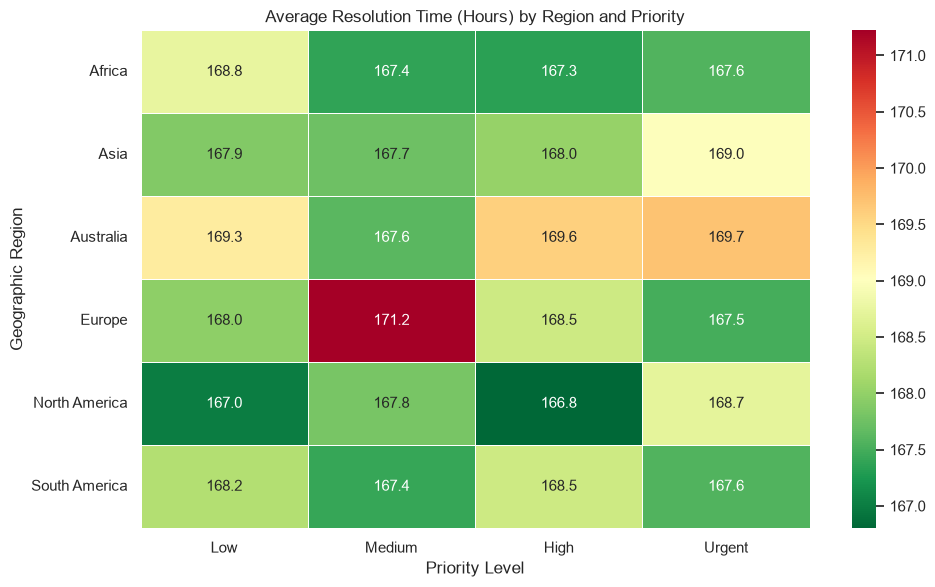

CRITICAL ALERT: There are currently 60289 High/Urgent tickets pending resolution.
Recommendation: Reallocate immediate Tier 3 resources to clear this specific backlog.


In [51]:
# --- Performance Heatmap (Resolution times across priorities and regions) ---
perf_summary = df.groupby(['region', 'priority'])['Resolution_Duration'].mean().unstack()
priority_order = ['Low', 'Medium', 'High', 'Urgent']
perf_summary = perf_summary[priority_order] # Reorder columns logically

plt.figure(figsize=(10, 6))
sns.heatmap(perf_summary, annot=True, cmap='RdYlGn_r', fmt=".1f", linewidths=.5)
plt.title('Average Resolution Time (Hours) by Region and Priority')
plt.ylabel('Geographic Region')
plt.xlabel('Priority Level')
plt.show()

# --- Geographic Volume Distribution ---
region_volume = df['region'].value_counts().reset_index()
region_volume.columns = ['Region', 'Ticket Volume']

# Using Plotly to create an interactive bar chart for Regional Volume
fig = px.bar(
    region_volume, 
    x='Region', 
    y='Ticket Volume', 
    color='Ticket Volume',
    color_continuous_scale='Blues',
    title='Ticket Concentration by Geographic Region'
)
fig.show()

# --- Detect High-Priority Unresolved Issues ---
# Assuming 'Closed' or 'Resolved' are the completion statuses in your dataset
high_priority_unresolved = df[
    (df['priority'].isin(['High', 'Urgent'])) & 
    (~df['status'].isin(['Resolved', 'Closed']))
]

print(f"CRITICAL ALERT: There are currently {len(high_priority_unresolved)} High/Urgent tickets pending resolution.")
print("Recommendation: Reallocate immediate Tier 3 resources to clear this specific backlog.")